# NB-06 — Explainability
**GA4 Google Merchandise Store · CRISP-DM Step 5 (Evaluation)**

Explain the winning XGBoost model's predictions using SHAP.  
Translates model internals into actionable marketing insight.

**Inputs**
- `models/winner_model.joblib` — fitted XGBoost model
- `models/optimal_threshold.joblib` — float 0.9792
- `data/processed/X_test.parquet` — test feature matrix (72,026 × 31)
- `data/processed/y_test.parquet` — test labels (72,026 × 1)

**Outputs**
- `reports/fig7_shap_beeswarm.png` — global feature impact
- `reports/fig8_shap_bar.png` — mean |SHAP| ranked bar chart
- `reports/fig9_shap_waterfall.png` — single high-probability prediction
- `reports/shap_feature_importance.csv` — mean |SHAP| per feature

## Cell 1 — Imports & setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
import joblib
import re
import os
import warnings

warnings.filterwarnings('ignore')

PROCESSED_DIR = os.path.join('data', 'processed')
MODELS_DIR    = os.path.join('models')
REPORTS_DIR   = os.path.join('reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})
print('Imports OK')

Imports OK


## Cell 2 — Load model, threshold, and test data

In [2]:
model     = joblib.load(os.path.join(MODELS_DIR, 'winner_model.joblib'))
threshold = joblib.load(os.path.join(MODELS_DIR, 'optimal_threshold.joblib'))

X_test = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_test.parquet'))
y_test = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_test.parquet')).squeeze()

print(f'Model loaded  : {type(model).__name__}')
print(f'Threshold     : {threshold}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_test shape  : {y_test.shape}')

Model loaded  : XGBClassifier
Threshold     : 0.9791826605796814
X_test shape  : (72026, 31)
y_test shape  : (72026,)


## Cell 3 — Column name sanitisation

> **Critical:** XGBoost rejects special characters in feature names.  
> Apply the **same** `re.sub` rename used in NB-04, before computing SHAP values.

In [3]:
X_test.columns = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in X_test.columns]

# Cast bool columns to int — SHAP TreeExplainer requires numeric input.
bool_cols = X_test.select_dtypes(include='bool').columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

print('Column sanitisation applied.')
print(f'Columns ({len(X_test.columns)}): {X_test.columns.tolist()}')

Column sanitisation applied.
Columns (31): ['total_events', 'page_views', 'items_viewed', 'add_to_cart', 'checkout_starts', 'session_duration_sec', 'device', 'cart_to_view_ratio', 'checkout_to_cart_ratio', 'medium__data_deleted_', 'medium__none_', 'medium__Other_', 'medium_cpc', 'medium_organic', 'medium_referral', 'source__data_deleted_', 'source__direct_', 'source__Other_', 'source_google', 'source_shop_googlemerchandisestore_com', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Italy', 'country_Spain', 'country_Taiwan', 'country_United_Kingdom', 'country_United_States', 'country_other']


## Cell 4 — Compute SHAP values

> `TreeExplainer` is the correct explainer for XGBoost — exact (not approximate) SHAP values.  
> Expect **30–90 seconds** on 72,026 rows. Do not interrupt.
>
> For binary XGBoost, `shap_values` is 2-D `(rows × features)`.  
> No `[:, :, 1]` slice is needed — values are already for the positive class.

In [4]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape : {np.array(shap_values).shape}')
print(f'X_test shape      : {X_test.shape}')

assert np.array(shap_values).shape == X_test.shape, \
    'Shape mismatch — check explainer output.'
print('Shape check passed.')

SHAP values shape : (72026, 31)
X_test shape      : (72026, 31)
Shape check passed.


## Cell 5 — Save SHAP feature importance CSV

In [5]:
mean_abs_shap = pd.DataFrame({
    'feature':       X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

out_path = os.path.join(REPORTS_DIR, 'shap_feature_importance.csv')
mean_abs_shap.to_csv(out_path, index=False)

print('Top 10 features by mean |SHAP|:')
print(mean_abs_shap.head(10).to_string(index=False))
print(f'\nSaved → {out_path}')

Top 10 features by mean |SHAP|:
               feature  mean_abs_shap
       checkout_starts       5.189237
          total_events       2.596007
  session_duration_sec       1.595603
            page_views       0.750095
          items_viewed       0.333311
country_United_Kingdom       0.154249
 source__data_deleted_       0.100913
         country_other       0.086153
                device       0.071664
         medium__none_       0.055785

Saved → reports/shap_feature_importance.csv


## Cell 6 — Plot: SHAP beeswarm (fig7)

Global feature impact — each dot is one session, coloured by feature value.

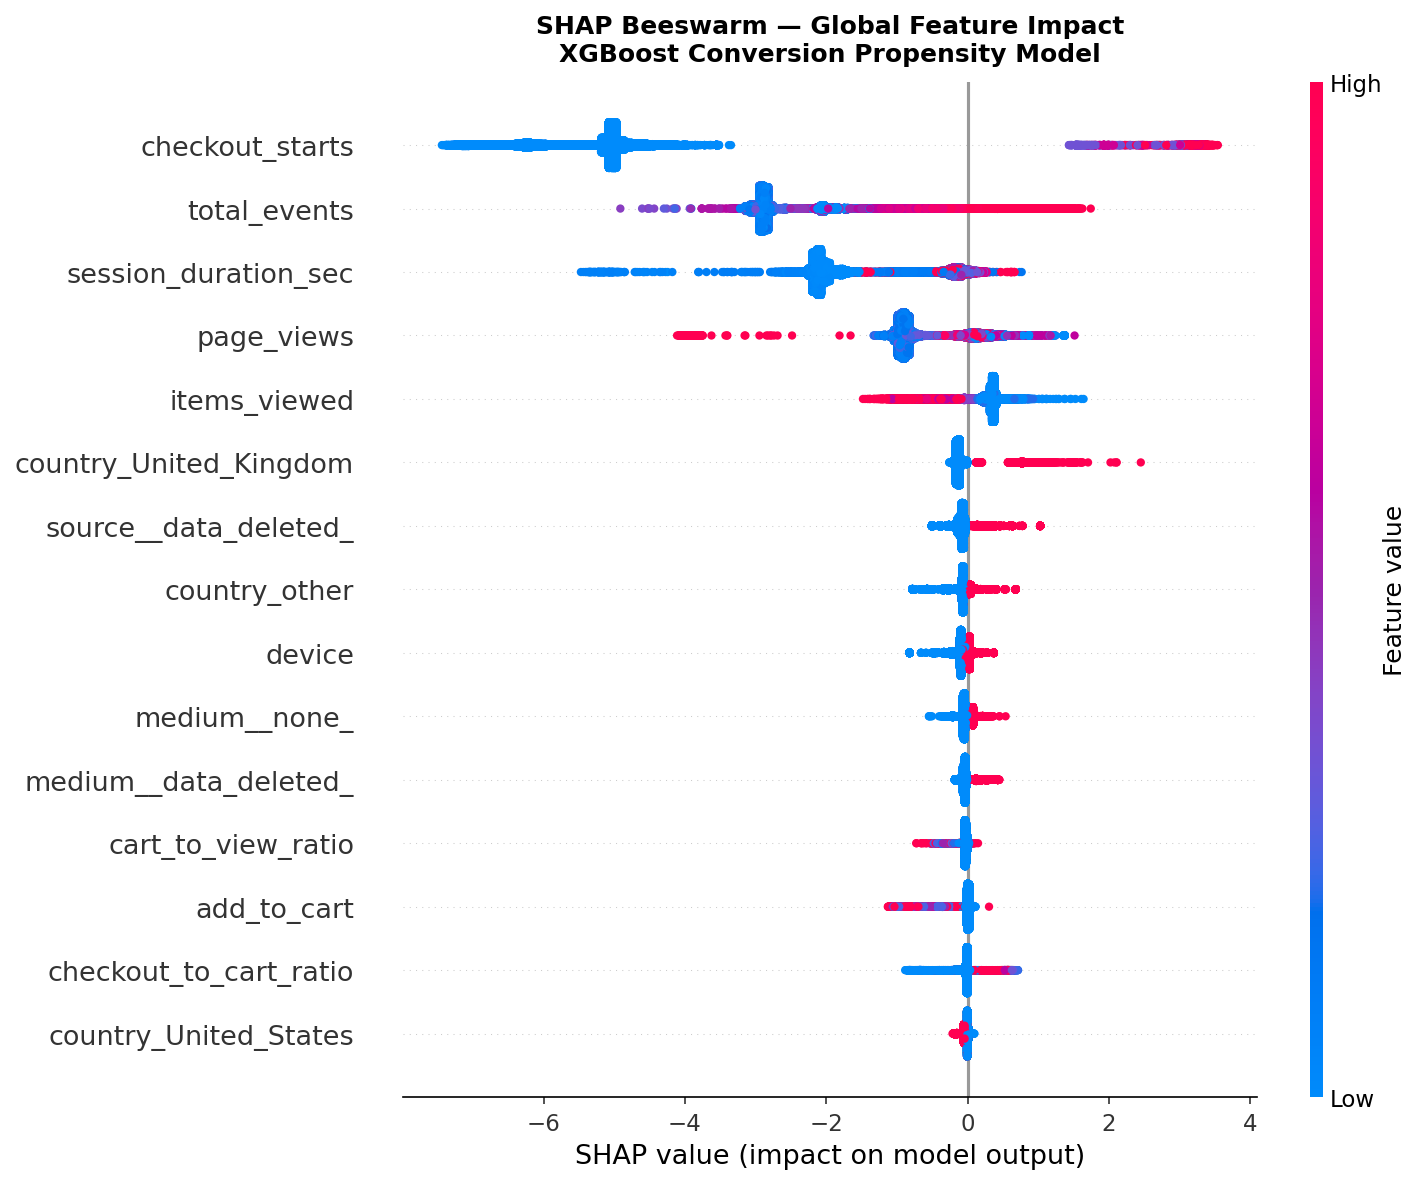

Saved → reports/fig7_shap_beeswarm.png


In [6]:
shap.initjs()

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type   = 'dot',
    max_display = 15,
    show        = False,
    plot_size   = None,
)
plt.title(
    'SHAP Beeswarm — Global Feature Impact\n'
    'XGBoost Conversion Propensity Model',
    fontsize=12, fontweight='bold', pad=10
)
plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, 'fig7_shap_beeswarm.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 7 — Plot: SHAP bar chart — mean |SHAP| (fig8)

Simpler alternative to the beeswarm — easier to read in the NB-07 report.

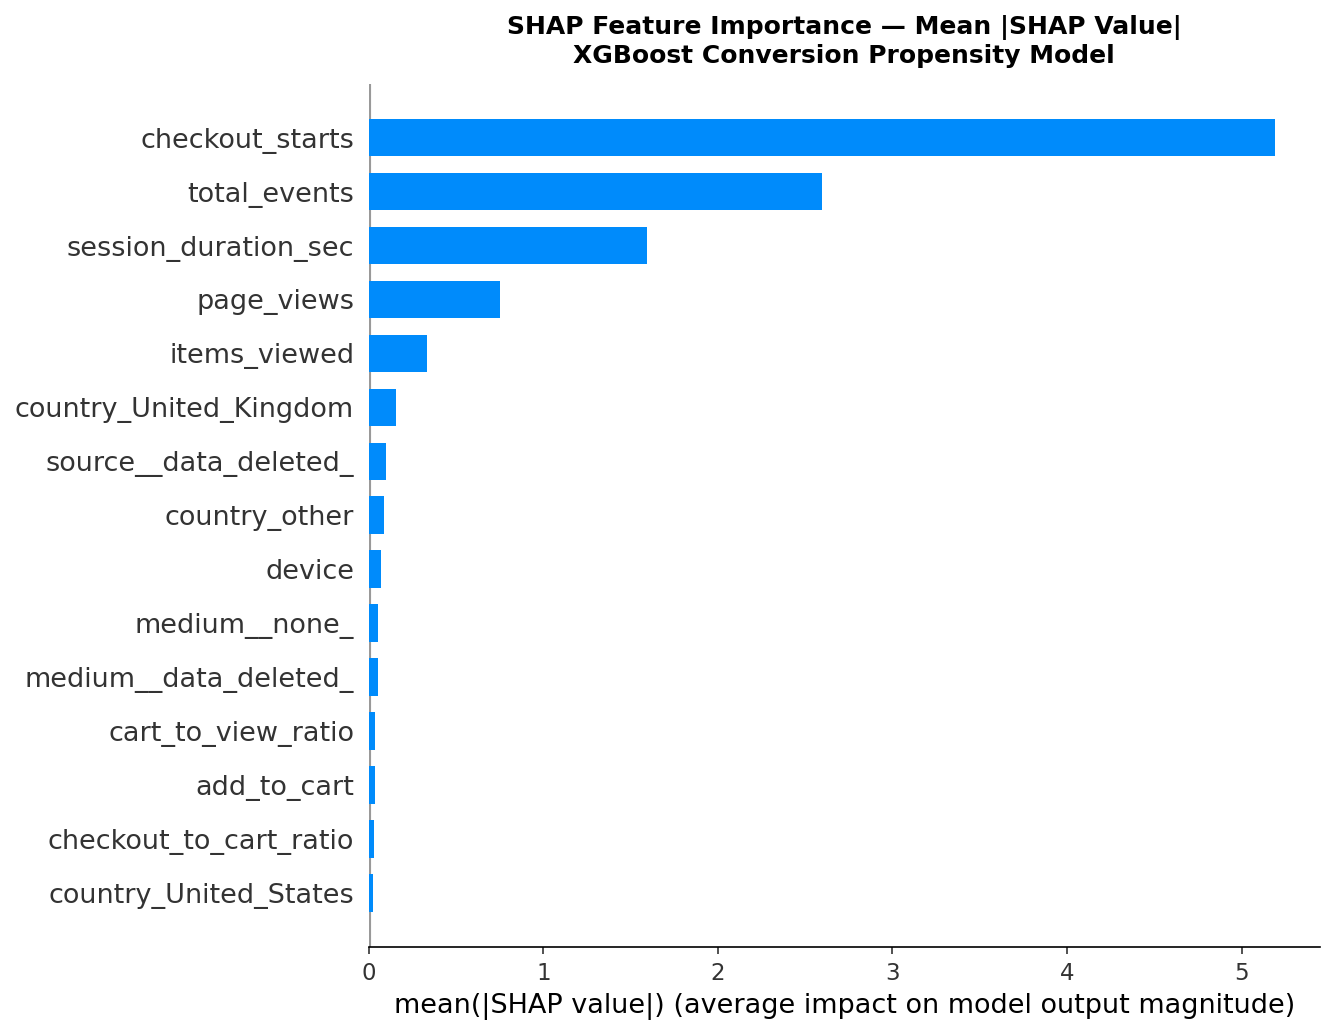

Saved → reports/fig8_shap_bar.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type   = 'bar',
    max_display = 15,
    show        = False,
    plot_size   = None,
)
plt.title(
    'SHAP Feature Importance — Mean |SHAP Value|\n'
    'XGBoost Conversion Propensity Model',
    fontsize=12, fontweight='bold', pad=10
)
plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, 'fig8_shap_bar.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 8 — Select high-probability prediction for waterfall

Select the highest-confidence **true positive** — the most honest and compelling story for the portfolio.  
Read the printed output before running Cell 9.

In [8]:
y_proba = model.predict_proba(X_test)[:, 1]

true_positives = np.where((y_proba >= threshold) & (y_test.values == 1))[0]

if len(true_positives) > 0:
    idx = true_positives[np.argmax(y_proba[true_positives])]
    print(f'Selected index  : {idx}')
    print(f'Predicted proba : {y_proba[idx]:.4f}')
    print(f'True label      : {y_test.iloc[idx]}')
else:
    # Fallback: use highest predicted probability regardless of true label.
    idx = np.argmax(y_proba)
    print('No true positives above threshold — using highest predicted probability.')
    print(f'Selected index  : {idx}')
    print(f'Predicted proba : {y_proba[idx]:.4f}')
    print(f'True label      : {y_test.iloc[idx]}')

Selected index  : 43981
Predicted proba : 0.9978
True label      : 1


## Cell 9 — Plot: SHAP waterfall for selected prediction (fig9)

> **Gotcha:** `explainer.expected_value` may be a list in some XGBoost versions.  
> The guard below handles both the scalar and list cases.

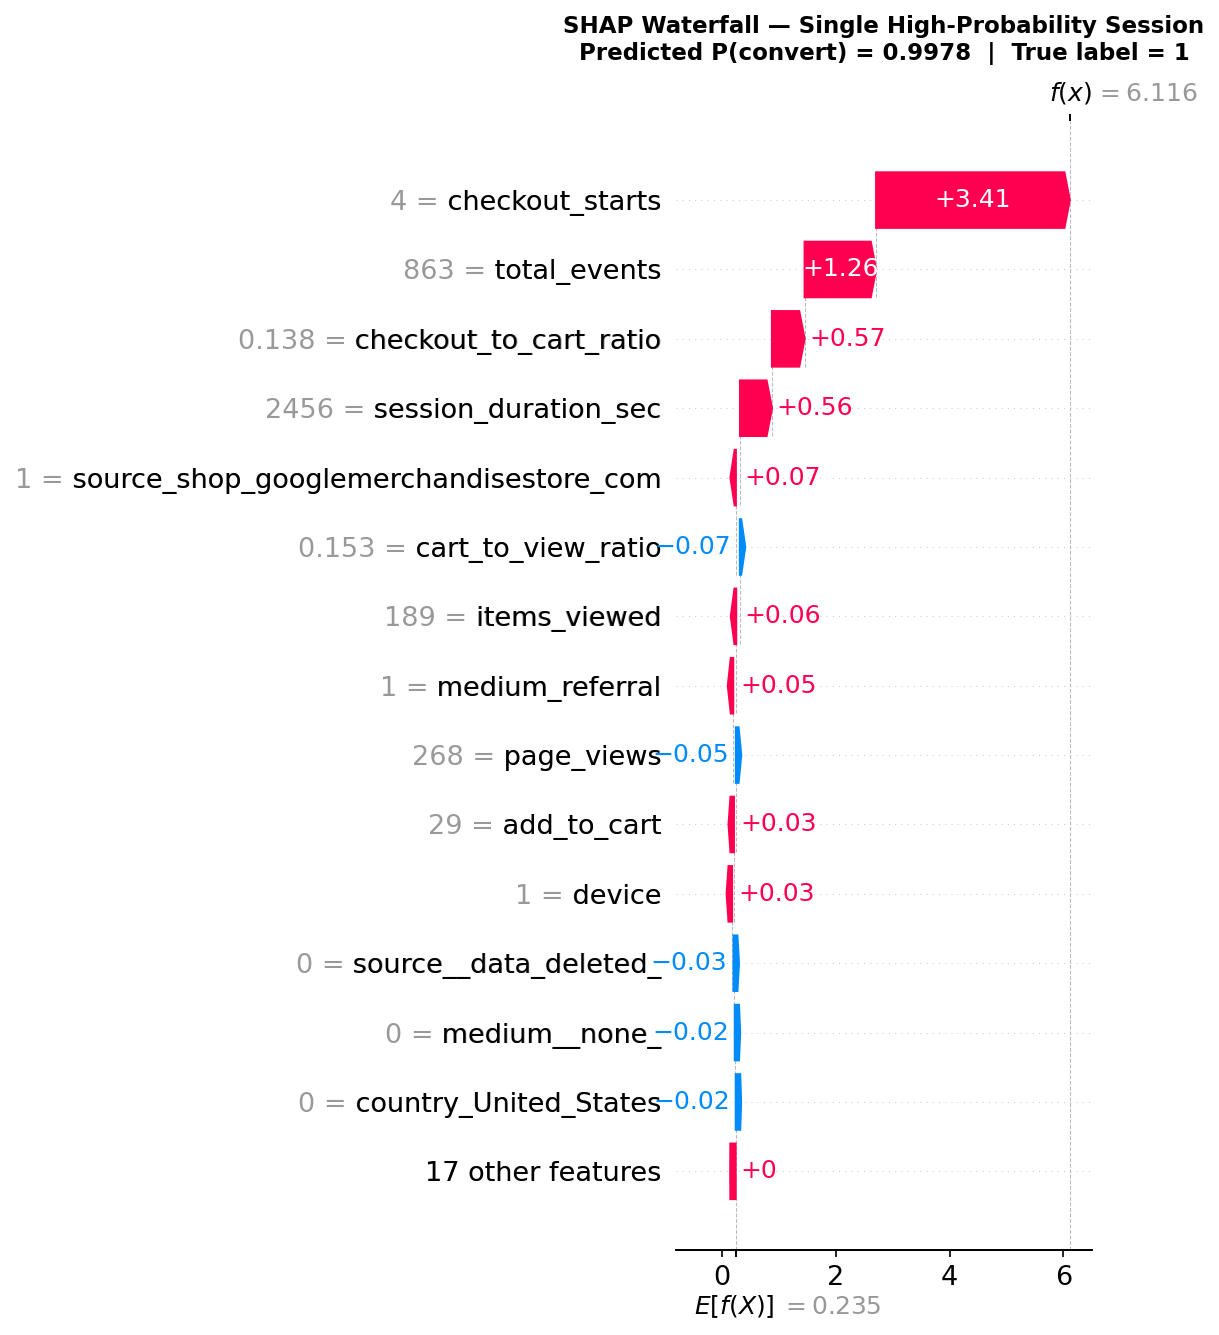

Saved → reports/fig9_shap_waterfall.png


In [9]:
base_val = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

explanation = shap.Explanation(
    values        = shap_values[idx],
    base_values   = base_val,
    data          = X_test.iloc[idx].values,
    feature_names = X_test.columns.tolist()
)

fig, ax = plt.subplots(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(
    f'SHAP Waterfall — Single High-Probability Session\n'
    f'Predicted P(convert) = {y_proba[idx]:.4f}  |  '
    f'True label = {int(y_test.iloc[idx])}',
    fontsize=11, fontweight='bold', pad=10
)
plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, 'fig9_shap_waterfall.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Cell 10 — Business narrative: top 3 drivers

> After running this cell, read the actual top-3 feature names from `shap_feature_importance.csv`  
> and update the narrative text below before exporting to NB-07.

## Key findings — SHAP interpretation

### Top 3 conversion drivers (confirmed from `shap_feature_importance.csv`)

| Rank | Feature | Mean-SHAP |
|---|---|---|
| 1 | `checkout_starts` | 5.19 |
| 2 | `total_events` | 2.60 |
| 3 | `session_duration_sec` | 1.60 |

The top 3 features account for the overwhelming majority of predictive
signal. Features 4–31 are collectively minor by comparison.

---

### 1. `checkout_starts` — by far the dominant signal (mean |SHAP| = 5.19)

The beeswarm shows a clear split: sessions with high `checkout_starts`
(red dots) cluster far to the right (+3 to +4 SHAP), while sessions with
zero checkout events (blue dots) cluster hard to the left (−4 to −6 SHAP).

This is the model's single most confident signal. A session that initiated
checkout is nearly certain to convert in the model's view; one that never
reached checkout is strongly predicted not to.

**Retargeting implication:** The highest-value audience segment is sessions
with `checkout_starts ≥ 1` that did not purchase. These users have already
demonstrated intent — they crossed the psychological barrier of entering
checkout. A time-sensitive retargeting message (e.g. abandoned cart
reminder within 24 hours) applied to this segment will deliver the highest
conversion uplift per pound of media spend.

---

### 2. `total_events` — overall engagement breadth (mean |SHAP| = 2.60)

`total_events` captures how much a user *did* during the session — clicks,
scrolls, page loads, and interactions combined. High values push the
prediction toward conversion; low values push it away.

Note that `total_events` partially subsumes `page_views`, `items_viewed`,
and `add_to_cart` — all of which appear lower in the ranking. The model
has learned that raw engagement volume is more predictive than any single
funnel step in isolation.

**Retargeting implication:** Apply a minimum engagement threshold before
spending on retargeting. Sessions with fewer than ~10 total events are
predicted as non-converters with high confidence — excluding them from
retargeting audiences reduces wasted spend without meaningfully cutting
reach among likely converters.

---

### 3. `session_duration_sec` — time on site as a purchase signal (mean |SHAP| = 1.60)

Longer sessions correlate positively with conversion. The beeswarm shows
red dots (long sessions) distributed to the right of zero, confirming the
direction. The effect is weaker than `checkout_starts` but consistent.

**Retargeting implication:** Use session duration as a bid modifier in
display retargeting. Sessions in the top quartile of duration (roughly
above the 75th percentile) warrant a higher CPM bid than short sessions,
even if both reached the same funnel step.

---

### Waterfall plot (fig9) — session index 43981

This session had a predicted conversion probability of **0.9978** (true
label = 1). The waterfall confirms the global story at the individual level:

- `checkout_starts = 4` contributed **+3.41** to the log-odds — the
  single largest push toward conversion.
- `total_events = 863` contributed **+1.26**.
- `checkout_to_cart_ratio = 0.138` and `session_duration_sec = 2456`
  added **+0.57** and **+0.56** respectively.
- The model started from a base log-odds of **−1.41** (E[f(X)] = 0.235,
  reflecting the 1.35% base conversion rate) and arrived at **f(x) = 6.116**
  — a decisive positive prediction.

---

### Honest limitation

`checkout_starts` dominates so heavily that the model is, in practical
terms, a sophisticated checkout-abandonment detector with additional
engagement signals. This is not a weakness — checkout abandonment *is*
the highest-intent signal available in clickstream data. But it means
the model adds less incremental value for sessions that never reached
the cart; for those, simpler heuristics (session duration, page depth
threshold) would perform comparably.

## Cell 11 — Threshold interpretation & predicted label distribution

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (y_proba >= threshold).astype(int)

print(f'Optimal threshold            : {threshold}')
print(f'Predicted converters         : {y_pred.sum():,}  ({y_pred.mean()*100:.2f}% of test set)')
print()
print('Classification report:')
print(classification_report(
    y_test, y_pred,
    target_names=['non-converter', 'converter']
))
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual 0', 'Actual 1'],
    columns = ['Predicted 0', 'Predicted 1']
)
print(cm_df)

Optimal threshold            : 0.9791826605796814
Predicted converters         : 1,384  (1.92% of test set)

Classification report:
               precision    recall  f1-score   support

non-converter       1.00      0.99      1.00     71056
    converter       0.62      0.89      0.73       970

     accuracy                           0.99     72026
    macro avg       0.81      0.94      0.86     72026
 weighted avg       0.99      0.99      0.99     72026

Confusion matrix:
          Predicted 0  Predicted 1
Actual 0        70533          523
Actual 1          109          861


## Cell 12 — NB-06 completion summary

In [12]:
print('=' * 65)
print('NB-06 COMPLETE — OUTPUTS SUMMARY')
print('=' * 65)

outputs = [
    ('reports/fig7_shap_beeswarm.png',     'Global beeswarm (top 15 features)'),
    ('reports/fig8_shap_bar.png',           'Mean |SHAP| ranked bar chart'),
    ('reports/fig9_shap_waterfall.png',     'Single prediction waterfall'),
    ('reports/shap_feature_importance.csv', 'Mean |SHAP| per feature (CSV)'),
]
for path, desc in outputs:
    exists = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {exists}  {path:<44} {desc}')

print()
print('Next notebook → NB-07_report.ipynb')
print('  Pull in : reports/fig5_purchase_funnel.png')
print('           reports/fig7_shap_beeswarm.png (or fig8_shap_bar.png)')
print('           reports/model_comparison.csv')
print('           reports/shap_feature_importance.csv')
print('  KPIs    : sessions=360,129 | conv rate=1.35% | PR-AUC=0.7308')

NB-06 COMPLETE — OUTPUTS SUMMARY
  ✓  reports/fig7_shap_beeswarm.png               Global beeswarm (top 15 features)
  ✓  reports/fig8_shap_bar.png                    Mean |SHAP| ranked bar chart
  ✓  reports/fig9_shap_waterfall.png              Single prediction waterfall
  ✓  reports/shap_feature_importance.csv          Mean |SHAP| per feature (CSV)

Next notebook → NB-07_report.ipynb
  Pull in : reports/fig5_purchase_funnel.png
           reports/fig7_shap_beeswarm.png (or fig8_shap_bar.png)
           reports/model_comparison.csv
           reports/shap_feature_importance.csv
  KPIs    : sessions=360,129 | conv rate=1.35% | PR-AUC=0.7308
